## 1. Import Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

## 2. Load data

In [21]:
# Load dataset tempat
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

print("Kolom:", df_place.columns.tolist())
print(f"\nJumlah tempat: {len(df_place)}")
print(f"\nKategori unik:")
print(df_place['main_category'].value_counts().head(400))

Kolom: ['place_id', 'name', 'description', 'is_spending_on_ads', 'reviews', 'rating', 'competitors', 'website', 'phone', 'can_claim', 'owner_name', 'owner_profile_link', 'featured_image', 'main_category', 'categories', 'workday_timing', 'is_temporarily_closed', 'closed_on', 'address', 'review_keywords', 'link', 'query']

Jumlah tempat: 872

Kategori unik:
main_category
Tujuan Wisata                  208
Biro Perjalanan dan Wisata     102
Hotel                           57
Kantor Perusahaan               39
Agen Sewa Mobil                 34
                              ... 
Tempat Parkir Sepeda Motor       1
Produsen                         1
Sekolah Agama                    1
Bed & Breakfast                  1
Operator wahana parasailing      1
Name: count, Length: 119, dtype: int64


In [22]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nicodwiputra/review-wisata/all-task-39-detailed-reviews.csv')

print("✅ Dataset berhasil dimuat!")
print(f"Shape: {df.shape}")
print(f"\nKolom ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

✅ Dataset berhasil dimuat!
Shape: (94209, 25)

Kolom (25):
  - place_id
  - place_name
  - review_id
  - review_link
  - name
  - reviewer_id
  - reviewer_profile
  - rating
  - review_text
  - original_language
  - review_translated_text
  - translated_language
  - published_at
  - published_at_date
  - response_from_owner_text
  - response_from_owner_ago
  - response_from_owner_date
  - response_from_owner_translated_text
  - avatar_link
  - total_number_of_reviews_by_reviewer
  - total_number_of_photos_by_reviewer
  - is_local_guide
  - experience_details
  - review_photos
  - review_origin


## 3. Cek Missing Values

In [23]:
# Lihat sample data
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Info Dataset ===")
df.info()

print("\n=== Distribusi Rating ===")
print(df['rating'].value_counts().sort_index())

print("\n=== Missing Values ===")
print(df[['review_text', 'rating', 'original_language']].isnull().sum())

=== 5 Baris Pertama ===


,place_id,place_name,review_id,review_link,name,reviewer_id,reviewer_profile,rating,review_text,original_language,...,response_from_owner_ago,response_from_owner_date,response_from_owner_translated_text,avatar_link,total_number_of_reviews_by_reviewer,total_number_of_photos_by_reviewer,is_local_guide,experience_details,review_photos,review_origin
0,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,ChZDSUhNMG9nS0VJQ0FnSUNadTVxTUt3EAE,https://www.google.com/maps/reviews/data=!4m8!...,Dimas Nurdian Syah Wahyudi,117740383702575191413,https://www.google.com/maps/contrib/1177403837...,4.0,NaN,NaN,...,Edited a week ago,2023-10-10T11:10:37,Dear Mr. Dimas Nurdian Syah Wahyudi.\n\nWarm g...,https://lh3.googleusercontent.com/a/ACg8ocKusK...,97,27,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google
1,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2xwMlVWQmFXRU0zZFhWQ2...,https://www.google.com/maps/reviews/data=!4m8!...,Rifka Faradisa,100422181349461110397,https://www.google.com/maps/contrib/1004221813...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:07:22,Dear Mrs. Rifka Faradisa\n\nA warm greeting fr...,https://lh3.googleusercontent.com/a/ACg8ocLNOL...,15,7,1.0,[],[],google
2,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2w5VE1HTlFhRWh5V0ZneF...,https://www.google.com/maps/reviews/data=!4m8!...,nugroho suksmanto,101113277062498619143,https://www.google.com/maps/contrib/1011132770...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:06:57,Dear Mr. Nugroho Suksmanto\n\nA warm greeting ...,https://lh3.googleusercontent.com/a/ACg8ocKpiB...,0,0,NaN,[],[],google
3,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2pKWE5YRldkMTluYkhaUG...,https://www.google.com/maps/reviews/data=!4m8!...,eric,109528954650929435012,https://www.google.com/maps/contrib/1095289546...,5.0,Trip Pertama 2026\nSumenep - Pamekasan\nHoteln...,id,...,3 weeks ago,2026-01-09T02:11:58,Dear Mr. Eric\n\nA warm greeting from FrontOne...,https://lh3.googleusercontent.com/a-/ALV-UjUj8...,169,424,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...","[{""id"":""CIABIhBlam7tesEKr2x8AXvz2aTG"",""url"":""h...",google
4,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2kxT1REUXphbTFoWjB0RF...,https://www.google.com/maps/reviews/data=!4m8!...,Rizky Afreza Febryanto,117434415881649210216,https://www.google.com/maps/contrib/1174344158...,5.0,Sangat menyenangkan menginap di hotel Front On...,id,...,3 weeks ago,2026-01-09T02:11:36,Dear Mr. Rizky Afreza\n\nA warm greeting from ...,https://lh3.googleusercontent.com/a-/ALV-UjUJd...,1034,6779,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94209 entries, 0 to 94208
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   place_id                             94209 non-null  object 
 1   place_name                           94209 non-null  object 
 2   review_id                            94209 non-null  object 
 3   review_link                          94209 non-null  object 
 4   name                                 94209 non-null  object 
 5   reviewer_id                          94068 non-null  object 
 6   reviewer_profile                     94209 non-null  object 
 7   rating                               94068 non-null  float64
 8   review_text                          48765 non-null  object 
 9   original_language                    48784 non-null  object 
 10  review_translated_text               44377 non-null  object 
 11  transl

## 4. Filter Kolom, Drop Missing Values, & Saring Kategori Wisata

In [24]:
# 1. Ambil kolom ulasan yang relevan saja
cols_needed = ['place_id', 'place_name', 'rating', 'review_text', 
               'original_language', 'published_at_date']
df_clean = df[cols_needed].copy()

# 2. Drop baris tanpa review_text atau rating
df_clean = df_clean.dropna(subset=['review_text', 'rating'])

# 3. Load dataset informasi tempat untuk filter kategori
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

# Tentukan kategori yang benar-benar masuk domain pariwisata & akomodasi
kategori_wisata = [
    'Tujuan Wisata', 'Hotel', 'Rumah wisata', 'Hostel', 
    'Penginapan', 'Biro Perjalanan dan Wisata', 'Biro Wisata'
]

# Ambil list place_id yang valid sebagai tempat wisata [cite: 172]
place_wisata_ids = df_place[df_place['main_category'].isin(kategori_wisata)]['place_id']

# 4. Filter df_clean agar HANYA menyimpan tempat wisata pendukung
df_tourist = df_clean[df_clean['place_id'].isin(place_wisata_ids)].copy()

print("=== HASIL FILTER KATEGORI WISATA ===")
print(f"Sebelum filter kategori : {len(df_clean):,} baris")
print(f"Setelah filter kategori : {len(df_tourist):,} baris")
print(f"Data non-wisata dibuang : {len(df_clean) - len(df_tourist):,} baris (ATM, SPBU, Bengkel, dll.)")

=== HASIL FILTER KATEGORI WISATA ===
Sebelum filter kategori : 48,624 baris
Setelah filter kategori : 23,121 baris
Data non-wisata dibuang : 25,503 baris (ATM, SPBU, Bengkel, dll.)


## 5. Filter Bahasa Indonesia & Visualisasi Distribusi Rating

Total review tempat wisata khusus bahasa Indonesia: 20,634 baris

=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===
rating
1.0     1310
2.0      791
3.0     2450
4.0     4309
5.0    11774
Name: count, dtype: int64


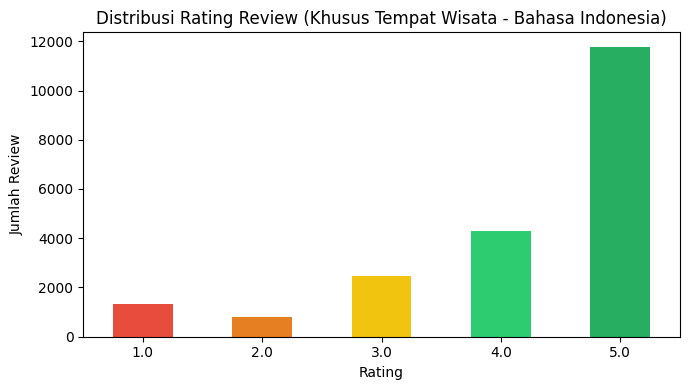

In [25]:
# Filter khusus ulasan bahasa Indonesia
df_id = df_tourist[df_tourist['original_language'] == 'id'].copy()
df_id = df_id.reset_index(drop=True)

print(f"Total review tempat wisata khusus bahasa Indonesia: {len(df_id):,} baris")

print("\n=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===")
print(df_id['rating'].value_counts().sort_index())

# Visualisasi distribusi rating setelah pembersihan kategori
plt.figure(figsize=(7,4))
df_id['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.title('Distribusi Rating Review (Khusus Tempat Wisata - Bahasa Indonesia)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

In [26]:
import re
import string

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)         # hapus mention/hashtag
    text = re.sub(r'\d+', '', text)               # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()      # hapus spasi berlebih
    return text

# Jalankan fungsi preprocessing pada data pariwisata yang sudah bersih
df_id['clean_text'] = df_id['review_text'].apply(preprocess)

print("✅ Pre-processing data pariwisata selesai!")
print(f"Total data siap pakai: {len(df_id):,} baris\n")

print("=== Sampel Hasil Preprocessing ===")
for _, row in df_id[['rating', 'review_text', 'clean_text']].sample(3, random_state=7).iterrows():
    print(f"\n⭐{int(row['rating'])}")
    print(f"  ASLI  : {row['review_text'][:100]}")
    print(f"  BERSIH: {row['clean_text'][:100]}")

✅ Pre-processing data pariwisata selesai!
Total data siap pakai: 20,634 baris

=== Sampel Hasil Preprocessing ===

⭐1
  ASLI  : Tepatnya jam 08.46
Sabtu 16 November 24
Satuan satuan lembaga MIS Nurut Taufiq lakukan rehalibitasi 
  BERSIH: tepatnya jam sabtu november satuan satuan lembaga mis nurut taufiq lakukan rehalibitasi kelas atap y

⭐5
  ASLI  : 😁
  BERSIH: 😁

⭐5
  ASLI  : Mantab n bagus
  BERSIH: mantab n bagus


## 7. Pembuatan Kandidat Custom Lexicon

In [27]:
from collections import Counter

# 1. Satukan seluruh teks bersih dan hitung kemunculan total tiap kosakata
semua_kata = " ".join(df_id['clean_text']).split()
hitung_kata = Counter(semua_kata)

data_kandidat_lexicon = []

# 2. Hitung kecenderungan rata-rata rating tempat suatu kata sering muncul
for kata, frekuensi in hitung_kata.items():
    if frekuensi >= 5: # Batasi ambang batas kemunculan kata agar terhindar dari noise typo kalimat
        # Temukan baris dokumen ulasan yang mengandung kata tersebut secara utuh
        ulasan_terkait = df_id[df_id['clean_text'].str.contains(rf'\b{kata}\b', regex=True, na=False)]
        
        if len(ulasan_terkait) > 0:
            rata_rating = ulasan_terkait['rating'].mean()
            data_kandidat_lexicon.append({'kata': kata, 'frekuensi': frekuensi, 'rata_rating': rata_rating})

# 3. Konversikan ke objek DataFrame kandidat kamus baru
df_kandidat_kamus = pd.DataFrame(data_kandidat_lexicon)

# 4. Rumus Normalisasi Linear: Mengubah rentang nilai rating (1 s.d 5) ke skala bobot desimal (-1 s.d 1)
df_kandidat_kamus['bobot'] = (df_kandidat_kamus['rata_rating'] - 3) / 2
df_kandidat_kamus['bobot'] = df_kandidat_kamus['bobot'].round(2)

print(f"✅ Berhasil mengekstrak {len(df_kandidat_kamus):,} kandidat kata kamus mandiri dari ulasan nyata!")

✅ Berhasil mengekstrak 3,968 kandidat kata kamus mandiri dari ulasan nyata!


## 8. Pemisahan Kamus & Injeksi Nilai Mutlak Objek Wisata

In [28]:
# Saring kata positif kuat (kata yang sering muncul di review bintang tinggi)
kamus_pos_custom = df_kandidat_kamus[df_kandidat_kamus['bobot'] > 0.25].sort_values(by='bobot', ascending=False).reset_index(drop=True)

# Saring kata negatif kuat (kata yang sering muncul di review bintang rendah)
kamus_neg_custom = df_kandidat_kamus[df_kandidat_kamus['bobot'] < -0.15].sort_values(by='bobot', ascending=True).reset_index(drop=True)

# Injeksi aturan manual (Overrides) untuk mengamankan akurasi kata esensial pariwisata daerah
aturan_positif = {'bagus': 1.0, 'indah': 1.0, 'nyaman': 1.0, 'bersih': 1.0, 'mantap': 1.0, 'keren': 1.0, 'luar biasa': 1.0, 'adem': 0.8}
aturan_negatif = {'kotor': -1.0, 'mahal': -0.8, 'kecewa': -1.0, 'jelek': -1.0, 'macet': -0.8, 'pungli': -1.0, 'kurang': -0.5}

# Terapkan pembaruan nilai override ke kamus positif buatan sendiri
for kata, bbt in aturan_positif.items():
    if kata in kamus_pos_custom['kata'].values:
        kamus_pos_custom.loc[kamus_pos_custom['kata'] == kata, 'bobot'] = bbt
    else:
        kamus_pos_custom = pd.concat([kamus_pos_custom, pd.DataFrame([{'kata': kata, 'frekuensi': 999, 'rata_rating': 5.0, 'bobot': bbt}])], ignore_index=True)

# Terapkan pembaruan nilai override ke kamus negatif buatan sendiri
for kata, bbt in aturan_negatif.items():
    if kata in kamus_neg_custom['kata'].values:
        kamus_neg_custom.loc[kamus_neg_custom['kata'] == kata, 'bobot'] = bbt
    else:
        kamus_neg_custom = pd.concat([kamus_neg_custom, pd.DataFrame([{'kata': kata, 'frekuensi': 999, 'rata_rating': 1.0, 'bobot': bbt}])], ignore_index=True)

print("=== TOP 5 KANDIDAT KATA POSITIF KAMUS MANDIRI ===")
print(kamus_pos_custom[['kata', 'frekuensi', 'bobot']].head(5))

print("\n=== TOP 5 KANDIDAT KATA NEGATIF KAMUS MANDIRI ===")
print(kamus_neg_custom[['kata', 'frekuensi', 'bobot']].head(5))

# Ekspor berkas CSV kamus rancangan sendiri untuk kebutuhan arsip proposal/sidang TA
kamus_pos_custom.to_csv('custom_lexicon_positif_madura.csv', index=False)
kamus_neg_custom.to_csv('custom_lexicon_negatif_madura.csv', index=False)
print("\n💾 Dua berkas kamus custom pariwisata Madura sukses diekspor ke format CSV!")

=== TOP 5 KANDIDAT KATA POSITIF KAMUS MANDIRI ===
        kata  frekuensi  bobot
0      kbihu         12    1.0
1     mabrur          9    1.0
2     kosnya          6    1.0
3       puri          6    1.0
4  eduwisata          8    1.0

=== TOP 5 KANDIDAT KATA NEGATIF KAMUS MANDIRI ===
        kata  frekuensi  bobot
0      marah         16   -1.0
1     bentak          5   -1.0
2       cong          7   -1.0
3  seenaknya          6   -0.9
4  alasannya          5   -0.9

💾 Dua berkas kamus custom pariwisata Madura sukses diekspor ke format CSV!


## 9. Labelling

In [29]:
# Konversikan DataFrame kamus buatan sendiri menjadi format dictionary agar komputasi loop berjalan kilat
dict_pos_custom = dict(zip(kamus_pos_custom['kata'], kamus_pos_custom['bobot']))
dict_neg_custom = dict(zip(kamus_neg_custom['kata'], kamus_neg_custom['bobot']))

def hitung_sentimen_hibrida(text, rating_asli):
    words = str(text).split()
    total_skor = 0
    
    # Akumulasikan nilai berdasarkan kemunculan kosakata di kamus custom
    for word in words:
        if word in dict_pos_custom:
            total_skor += dict_pos_custom[word]
        if word in dict_neg_custom:
            total_skor += dict_neg_custom[word]
            
    # Aturan keputusan kombinasi hibrida (Kamus + Kepuasan Rating Eksplisit)
    if total_skor > 0.1:
        return 'positif'
    elif total_skor < -0.1:
        return 'negatif'
    else:
        # Jika total skor bernilai samar/netral di kamus, selamatkan berdasarkan angka bintang asli
        if rating_asli >= 4.0:
            return 'positif'
        elif rating_asli == 3.0:
            return 'netral'
        else:
            return 'negatif'

# Eksekusi kalkulasi pelabelan akhir pada DataFrame utama
df_id['label'] = df_id.apply(lambda row: hitung_sentimen_hibrida(row['clean_text'], row['rating']), axis=1)

print("=== DISTRIBUSI KELAS LABEL SENTIMEN AKHIR ===")
print(df_id['label'].value_counts())
print("\n=== PERSENTASE PROPORSI KELAS ===")
print(df_id['label'].value_counts(normalize=True) * 100)


=== DISTRIBUSI KELAS LABEL SENTIMEN AKHIR ===
label
positif    20344
negatif      239
netral        51
Name: count, dtype: int64

=== PERSENTASE PROPORSI KELAS ===
label
positif    98.594553
negatif     1.158282
netral      0.247165
Name: proportion, dtype: float64


## 10. Split Data

In [30]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (teks bersih) dan target (label sentimen)
X = df_id['clean_text'].values
y = df_id['label'].map({'negatif': 0, 'netral': 1, 'positif': 2}).values

# Split pertama: 80% Train, 20% Temporary (untuk Val & Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split kedua: Bagi data temporary menjadi 50% Validation dan 50% Testing (masing-masing 10% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"📊 Ukuran Data Latih (Train) : {X_train.shape[0]:,} sampel")
print(f"📊 Ukuran Data Validasi (Val) : {X_val.shape[0]:,} sampel")
print(f"📊 Ukuran Data Uji (Test)     : {X_test.shape[0]:,} sampel")

📊 Ukuran Data Latih (Train) : 16,507 sampel
📊 Ukuran Data Validasi (Val) : 2,063 sampel
📊 Ukuran Data Uji (Test)     : 2,064 sampel


## 11. Menghitung Bobot Kelas (Class Weights)

In [31]:
import torch
from sklearn.utils.class_weight import compute_class_weight

# Hitung bobot kelas secara otomatis menggunakan scikit-learn
weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# Konversikan menjadi PyTorch Tensor agar siap dimasukkan ke fungsi Loss (CrossEntropyLoss)
class_weights = torch.tensor(weights, dtype=torch.float)

print("=== BOBOT PENALTI KELAS (CLASS WEIGHTS) ===")
print(f" - Bobot Kelas 0 [Negatif] : {class_weights[0].item():.4f}")
print(f" - Bobot Kelas 1 [Netral]  : {class_weights[1].item():.4f}")
print(f" - Bobot Kelas 2 [Positif] : {class_weights[2].item():.4f}")

=== BOBOT PENALTI KELAS (CLASS WEIGHTS) ===
 - Bobot Kelas 0 [Negatif] : 28.8080
 - Bobot Kelas 1 [Netral]  : 134.2032
 - Bobot Kelas 2 [Positif] : 0.3381


## 12. Modelling

### 12.1. Tokenizer

In [32]:
from transformers import AutoTokenizer

# 1. Unduh pretrained tokenizer IndoBERTweet dari Hugging Face
print("⏳ Memuat Tokenizer IndoBERTweet...")
tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased", use_fast=True)
print("✅ Tokenizer berhasil dimuat!\n")

# 2. Lakukan tokenisasi (Encoding) untuk data Train, Val, dan Test
# Kita batasi max_length=128 karena teks ulasan Google Maps pariwisata umumnya ringkas
MAX_LEN = 128

print("⏳ Mengonversi teks ulasan menjadi token ID...")
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")
val_encodings   = tokenizer(list(X_val), truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")
test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")

print("✅ Proses tokenisasi seluruh dataset selesai!")
print(f"Dimensi tensor input data latih: {train_encodings['input_ids'].shape}")

⏳ Memuat Tokenizer IndoBERTweet...
✅ Tokenizer berhasil dimuat!

⏳ Mengonversi teks ulasan menjadi token ID...
✅ Proses tokenisasi seluruh dataset selesai!
Dimensi tensor input data latih: torch.Size([16507, 128])


### 12.2. Batch

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Definisikan kelas wrapper untuk PyTorch Dataset
class UlasanPariwisataDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# 2. Bungkus masing-masing subset data
train_dataset = UlasanPariwisataDataset(train_encodings, y_train)
val_dataset   = UlasanPariwisataDataset(val_encodings, y_val)
test_dataset  = UlasanPariwisataDataset(test_encodings, y_test)

# 3. Tentukan Batch Size (Sesuai saran pengujian hyperparameter di jurnal)
# Kita pilih BATCH_SIZE = 16 untuk menjaga kestabilan memori GPU lokal
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ PyTorch DataLoader berhasil dikonfigurasi!")
print(f" - Total Batch pada Data Latih   : {len(train_loader)} batch")
print(f" - Total Batch pada Data Validasi: {len(val_loader)} batch")

✅ PyTorch DataLoader berhasil dikonfigurasi!
 - Total Batch pada Data Latih   : 1032 batch
 - Total Batch pada Data Validasi: 129 batch
